In [1]:
%load_ext autoreload
%autoreload 2

from scripts.lattice import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *

import seaborn as sns
#color_list = sns.color_palette() + sns.color_palette("Set2") + sns.color_palette("Set3")
color_list = (
    sns.color_palette("colorblind", 10) +
    sns.color_palette("Dark2", 8) +
    sns.color_palette("tab20", 20)
)

dim = 3
save_dir = f'data/{dim}d/rpa'

# single run with and without refinent (maybe also compare with tprc method)
# rest with more runs

Starting serial run at: 2026-05-19 11:48:21.895492


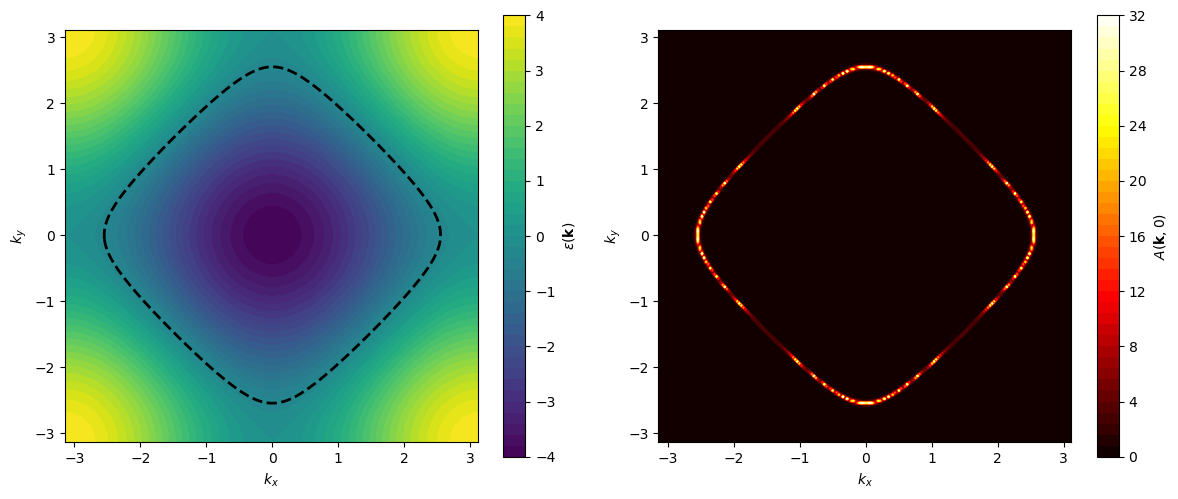

In [36]:
import numpy as np
import matplotlib.pyplot as plt

square = LATTICE(dim=2, tp=0.)
nk = 200

square.get_e_k(nk)
eps = square.e_k.data[:, 0, 0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

# --- Compute A(k,0) ---
eta = 0.01  # broadening, tune to ~pi*T or Im Sigma(0)
mu = get_mu(e_k=square.e_k, n_goal=0.9, beta=1/1)
Ak0 = (1/np.pi) * eta / (eta**2 + (eps - mu)**2)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: dispersion + bare FS ---
ax = axes[0]
cf = ax.contourf(kx, ky, eps, levels=50)
plt.colorbar(cf, ax=ax, label=r'$\varepsilon(\mathbf{k})$')
ax.contour(kx, ky, eps, levels=[mu], colors='black', linewidths=2)
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

# --- Plot 2: A(k,0) ---
ax = axes[1]
cf2 = ax.contourf(kx, ky, Ak0, levels=50, cmap='hot')
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
#ax.contour(kx, ky, eps, levels=[mu], colors='cyan', linewidths=1, linestyles='--')
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

-0.2 [-0.8399053199761002, -0.6919498838006279, -0.47658709313787545]
0.0 [-0.4269061742971663, -0.1801275395682463, 0.0]
0.2 [-0.11153337844605017, 0.20753242312156925, 0.47658709313792585]


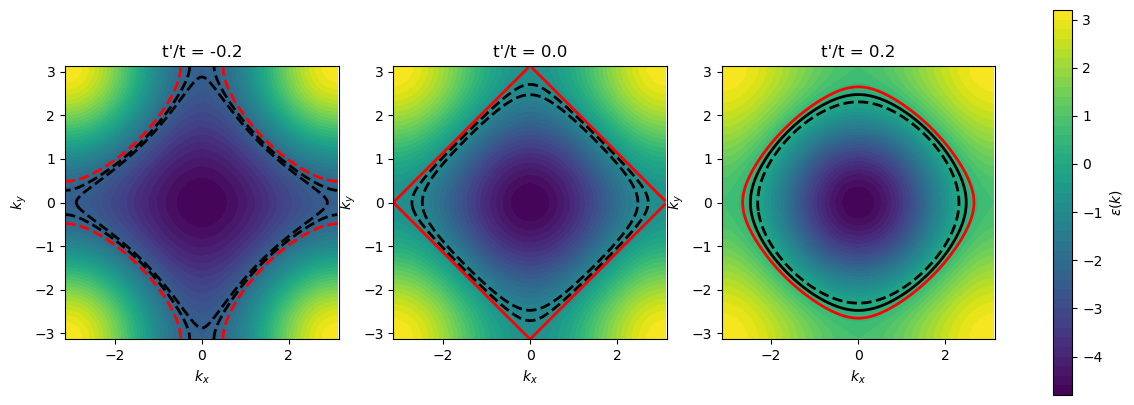

In [39]:
import numpy as np
import matplotlib.pyplot as plt

tp_list = [-0.2, 0., 0.2]

nk = 200

k_mesh, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

T = 0.01
n_list = [0.8, 0.9, 1.]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, tp in zip(axes, tp_list):
    square = LATTICE(dim=2, tp=tp)
    
    square.get_e_k(nk)
    eps = square.e_k.data[:, 0, 0].real
    eps = eps.reshape(nk, nk)
    eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

    cf = ax.contourf(kx, ky, eps, levels=50)

    mu_list = [get_mu(e_k=square.e_k, n_goal=n, beta=1/T) for n in n_list]
    print(tp, mu_list)
    ax.contour(kx, ky, eps, levels=mu_list[:-1], colors='black', linewidths=2)
    ax.contour(kx, ky, eps, levels=[mu_list[-1]], colors='red', linewidths=2)

    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_title(f"t'/t = {tp}")
    ax.set_aspect('equal')

fig.colorbar(cf, ax=axes, label=r'$\varepsilon(k)$')
plt.show()

In [ ]:
n = 0.7
T_list = np.linspace(0.001, 0.1, 10)
U = 3

nk = 200
cube = LATTICE()
cube.get_e_k(nk=nk)
cube.get_phase_k(nk)

fig = plt.figure(figsize=(14, 5))
ax = [fig.add_subplot(1,2,1),
    fig.add_subplot(1,2,2)]

ax[0].set_xlabel('$q_z$')
ax[0].set_ylabel(r'$\chi^{-1}(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel(r'$\chi^{-1}(\mathbf{Q}_{min})$')

qz_path = np.linspace(0., 1., nk//2+1)
Qz = []
Qz_refined = []
for i, T in enumerate(T_list):
    mu = get_mu(cube.e_k, n, 1/T)

    invchi = []
    for qz in qz_path:
        q = np.array([1.,1.,qz])

        e_k, e_kq = cube.get_e_kq(q, 'coarse')
        S_k = e_k*0
        invchi.append(1/lindhard_ksp(mu, 1/T, e_k, e_kq, S_k, S_k) - U)

    if i%2 == 0:
        ax[0].plot(qz_path, invchi, 'o-', markersize=3, label=f'T = {T:.3f}')

    idx = np.argmin(invchi)
    Qz.append(qz_path[np.argmin(invchi)])
    #ax[0].axvline(Qz[-1], linestyle='--', color=color)

    start = qz_path[0]
    end   = qz_path[-1]
    step  = 1 / (len(qz_path) - 1)

    def invchi0(s):

        qz_pt = start + s * (end - start)
        q_pt = np.array([1.,1.,qz_pt])
        e_k_arr, e_kq_arr = cube.get_e_kq(q_pt, 'fine')

        return 1/lindhard_ksp(mu, 1/T, e_k_arr, e_kq_arr, S_k, S_k) - U

    s0 = idx / (len(qz_path) - 1)
    res = minimize_scalar(invchi0, method='bounded', bounds=(max(0, s0 - 5*step), min(1, s0 + 5*step)))

    s_min = res.x
    Qz_refined.append(start + s_min * (end - start))
    
ax[1].plot(T_list, Qz, 'o-', markersize=4, color='steelblue')
ax[1].plot(T_list, Qz_refined, '--', markersize=4, color='steelblue')
ax[0].legend()

for a in ax:
    a.grid()
plt.show()

KeyboardInterrupt: 

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.


Starting serial run at: 2026-05-19 11:48:31.993152
Starting serial run at: 2026-05-19 11:48:31.993225
Starting serial run at: 2026-05-19 11:48:31.993292
[Parallel(n_jobs=3)]: Done   2 out of   6 | elapsed:   26.8s remaining:   53.6s
[Parallel(n_jobs=3)]: Done   3 out of   6 | elapsed:   28.3s remaining:   28.3s
[Parallel(n_jobs=3)]: Done   4 out of   6 | elapsed:   53.0s remaining:   26.5s
[Parallel(n_jobs=3)]: Done   6 out of   6 | elapsed:  1.0min finished


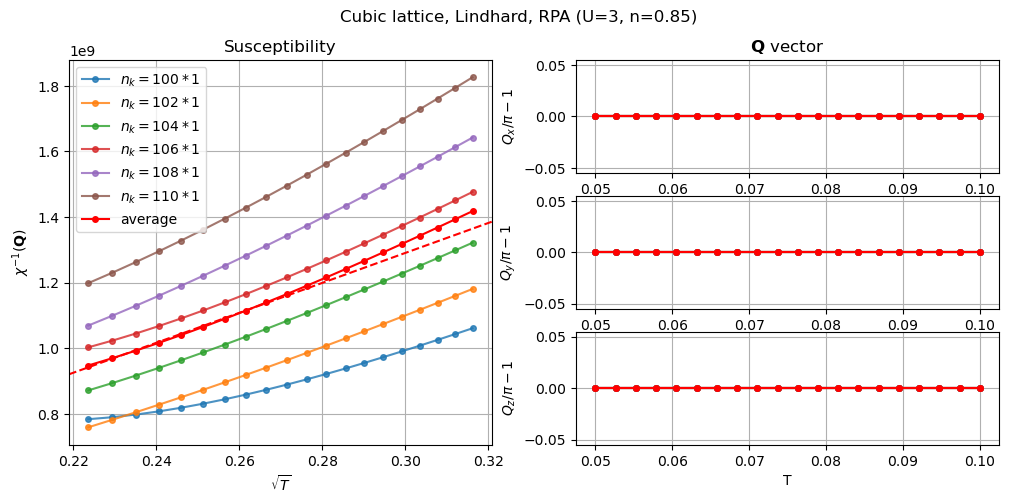

In [2]:
U = 3
n = 0.85
T_list = np.linspace(0.05, 0.1, 20)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Lindhard, RPA (U={U}, n={n})'

tp = 0.
nk_list = list(range(100, 111, 2))
refine_ratio = 1
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'lindhard', 'q_path': ([1,1,0],[1,1,1]), 'tp': tp, 
               'refine': True, 'refine_ratio': refine_ratio, 'ibz': True} for nk in nk_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=3)

results_avg = results_list[-1].copy()
results_avg['invchi'] = sum([results['invchi'] for results in results_list])/len(results_list)
results_avg['Q'] = sum([results['Q'] for results in results_list])/len(results_list)

fig = None
for results in results_list:
    nk = results['nk']
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=0.5,
                        title=title, label=f'$n_k={nk}*{refine_ratio}$', figure=fig, alpha=0.8)
    
fig, _ = pcut_chi(results_avg, 'T', plot_Q=(1,1,1), fit=True, x_exp=0.5,
                    title=title, label=f'average', figure=fig, color='red')

plt.show()

In [2]:
lat = LATTICE()

nk=40
lat.get_bz(nk, ibz=True)
lat.get_e_k()
e_kq = lat.get_e_kq(lat.e_k, [0,0,0], nk, ibz=True, method='coarse')
print(np.allclose(e_kq, lat.e_k))

lat.get_bz(nk, ibz=False)
lat.get_e_k()
e_kq_full = lat.get_e_kq(lat.e_k, [1,0,0], nk, ibz=False, method='coarse')

lat.get_bz(nk, ibz=True)
lat.get_e_k()
e_kq_ibz = lat.get_e_kq(lat.e_k, [1,0,0], nk, ibz=True, method='coarse')

print(np.allclose(lat.unfold_e_k(e_kq_ibz), e_kq_full))

ValueError: operands could not be broadcast together with shapes (64000,) (1771,) 

In [4]:
U = 3
n = 0.7
T_list = np.linspace(0.005, 0.01, 15)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Lindhard, RPA (U={U}, n={n})'

tp = 0.
nk_list = list(range(120, 151, 6))
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'lindhard', 'q_path': ([1,1,0], [1,1,1]), 'tp': tp, 'refine': True} for nk in nk_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=3)

results_avg = results_list[-1].copy()
results_avg['invchi'] = sum([results['invchi'] for results in results_list])/len(results_list)
results_avg['Q'] = sum([results['Q'] for results in results_list])/len(results_list)

fig = None
for results in results_list:
    nk = results['nk']
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=0.5,
                        title=title, label=f'$n_k={nk}$', figure=fig, alpha=0.8)
    
fig, _ = pcut_chi(results_avg, 'T', plot_Q=(0,0,1), fit=True, x_exp=0.5,
                    title=title, label=f'average', figure=fig, color='red')

plt.show()

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.


Starting serial run at: 2026-05-18 23:21:17.286138
Starting serial run at: 2026-05-18 23:21:17.322040
Starting serial run at: 2026-05-18 23:21:17.322791


KeyboardInterrupt: 

In [ ]:
U = 3
n_list = np.linspace(0.7, 0.9, 5)
T_list = np.concatenate([np.linspace(0.005, 0.01, 15), np.linspace(0.05, 1., 30)])
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 50
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=5)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc = results['Xc']
    ampl = results['ampl']
    gamma = results['gamma']
    print(f"n = {n} : ampl = {ampl}, exp = {gamma}, Tc = {Tc}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=0.5, fit=True,
                        title=title, label=f'n = {n}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    axs[0].scatter(-fit[1]/fit[0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


Starting serial run at: 2026-05-17 19:02:02.357983
Starting serial run at: 2026-05-17 19:02:02.362094
Starting serial run at: 2026-05-17 19:02:02.364677
Starting serial run at: 2026-05-17 19:02:02.386185
Starting serial run at: 2026-05-17 19:02:02.387778


ValueError: need at least one array to stack

In [ ]:
U = 3
n_list = np.linspace(0.83, 0.85, 5)
T_list = np.concatenate([np.linspace(0.005, 0.01, 15)])
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 80
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'matsubara', 'niw': 128, 'tp': 0.1, 'refine': True, 'refine_ratio': 2} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=5)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc = results['Xc']
    ampl = results['ampl']
    gamma = results['gamma']
    print(f"n = {n} : ampl = {ampl}, exp = {gamma}, Tc = {Tc}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=0.5, fit=True,
                        title=title, label=f'n = {n}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    axs[0].scatter(-fit[1]/fit[0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


Starting serial run at: 2026-05-17 20:43:05.314750
Starting serial run at: 2026-05-17 20:43:05.328420
Starting serial run at: 2026-05-17 20:43:05.389915
Starting serial run at: 2026-05-17 20:43:05.426146
Starting serial run at: 2026-05-17 20:43:05.448812


In [ ]:
U = 3
n_list = np.linspace(0.8, 0.85, 5)
T_list = np.concatenate([np.linspace(0.01, 0.05, 15)])
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 150
niw = 128
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': 0.1, 'method': 'matsubara', 'niw': niw, 'niw_extr': True, 'refine': False} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=5)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc = results['Xc']
    ampl = results['ampl']
    gamma = results['gamma']
    print(f"n = {n} : ampl = {ampl}, exp = {gamma}, Tc = {Tc}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=0.5, fit=True,
                        title=title, label=f'n = {n}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    axs[0].scatter(-fit[1]/fit[0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


KeyboardInterrupt: 

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:   13.1s finished


fit1: n = 0.88 : exp = 0.04817021152985477, ampl = 6.325598375450103
fit2: n = 0.88 : exp = 0.8024759193677553, ampl = 0.9525524691943074
fit1: n = 0.89 : exp = 2.6840319483046398, ampl = 6.575997586244648
fit2: n = 0.89 : exp = 1.3794061184190802, ampl = 3.9224447031630905
fit1: n = 0.9 : exp = 1.6642749397962295, ampl = 3.3350502239803257
fit2: n = 0.9 : exp = 1.1180186691259415, ampl = 3.244677345991099


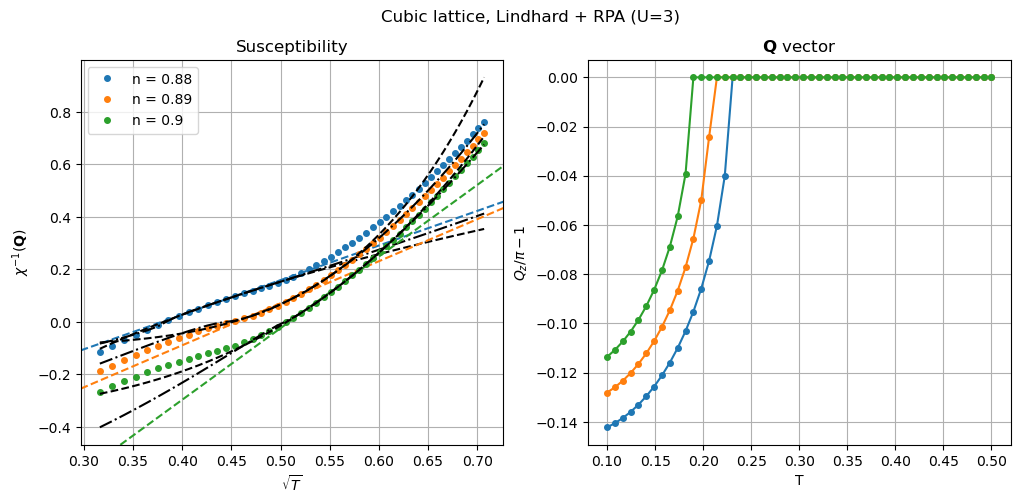

In [14]:
U = 3
n_list = np.linspace(0.88, 0.9, 3)
T_list = np.linspace(0.1, 0.5, 50)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard + RPA (U={U})'

nk = 50
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'fit_type': [critical1, critical2]} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=3)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    ampl = results['ampl']
    gamma = results['gamma']
    c = results['c']
    print(f'fit1: n = {n} : exp = {gamma[0]}, ampl = {ampl[0]}')
    print(f'fit2: n = {n} : exp = {gamma[1]}, ampl = {ampl[1]}')
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), fit=True, x_exp=0.5,
                        title=title, label=f'n = {n}', figure=fig, styles=('o','o-'))

    _, axs = fig
    axs[0].plot(T_list**0.5, critical1(T_list, ampl[0], gamma[0], c[0]), '--', color='black')
    axs[0].plot(T_list**0.5, critical2(T_list, ampl[1], gamma[1], c[1]), '-.', color='black')

plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-08 08:47:09.601029
Starting serial run at: 2026-05-08 08:47:09.602177
Starting serial run at: 2026-05-08 08:47:09.609273
Starting serial run at: 2026-05-08 08:47:09.638499
Starting serial run at: 2026-05-08 08:47:09.638526
Starting serial run at: 2026-05-08 08:47:09.649912
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:    2.5s remaining:    5.0s
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:    2.5s remaining:    2.5s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:    2.6s remaining:    1.3s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:    2.6s finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:   33.5s remaining:  1.1min
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:   34.1s remaining:   34.1s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:   34.2s remaining:   17.1s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:   34.5s finished

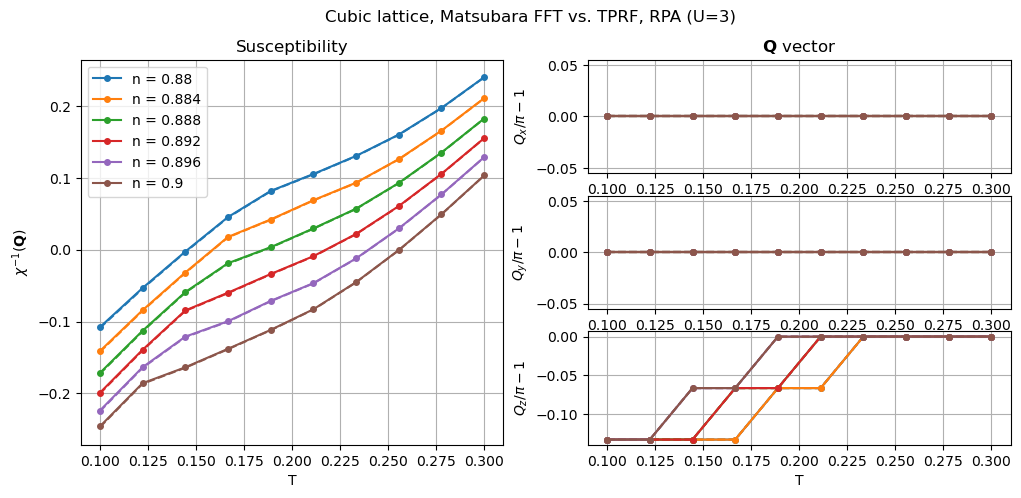

In [ ]:
U = 3
n_list = np.linspace(0.88, 0.9, 6)
T_list = np.linspace(0.1, 0.3, 10)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Matsubara FFT vs. TPRF, RPA (U={U})'

nk = 30
niw = 64
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'matsubara_fft', 'niw': niw, 'niw_extr': True} for par_dict in par_list]
results_list_fft = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'matsubara_tprf', 'niw': niw} for par_dict in par_list]
results_list_tprf = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for res_fft, res_tprf in zip(results_list_fft, results_list_tprf):
    n = res_fft['par_list'][0]['n']
    fig, fit = pcut_chi(res_fft, 'T', plot_Q=(1,1,1),
                        title=title, label=f'n = {n}', figure=fig)
    _, ax = fig
    color = ax[0].lines[-1].get_color()
    fig, fit = pcut_chi(res_tprf, 'T', plot_Q=(1,1,1),
                        title=title, figure=fig, color=color, styles=('--','--'))

plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:   24.5s remaining:   49.1s
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:   24.6s remaining:   24.6s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:   24.6s remaining:   12.3s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:   24.8s finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:    3.3s remaining:    6.6s
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:    3.5s remaining:    3.5s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:    3.6s remaining:    1.8s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:    3.9s finished


n = 0.88 : exp_mats = 0.00459947385692727, exp_lindh = 0.6090094017234252
n = 0.884 : exp_mats = 1.5042907976424826, exp_lindh = 1.4066120748489646
n = 0.888 : exp_mats = 3.0881358593315054, exp_lindh = 3.1278245090513668
n = 0.892 : exp_mats = 2.557290557810163, exp_lindh = 2.5585820870013025
n = 0.896 : exp_mats = 2.1905518747293957, exp_lindh = 2.191427703925661
n = 0.9 : exp_mats = 1.9623109816835178, exp_lindh = 1.962990711041491


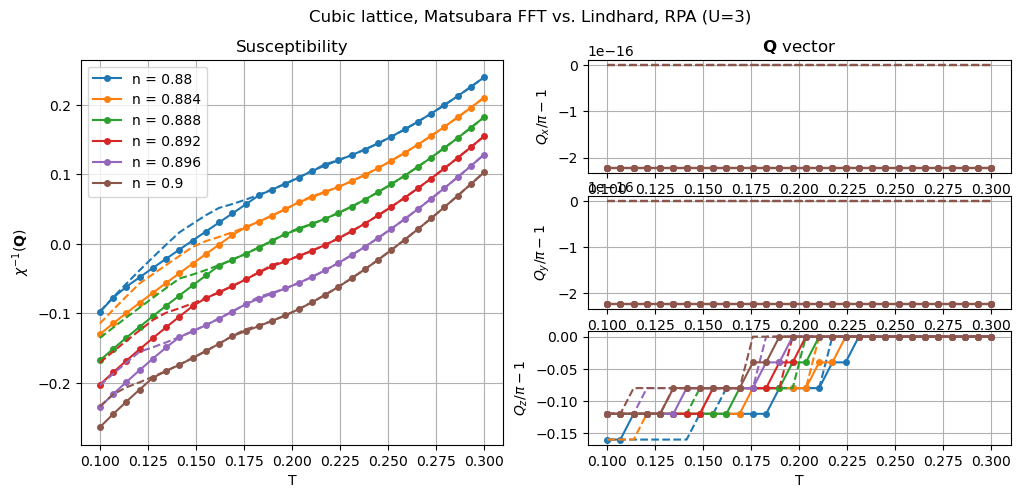

In [ ]:
U = 3
n_list = np.linspace(0.88, 0.9, 6)
T_list = np.linspace(0.1, 0.3, 30)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Matsubara FFT vs. Lindhard, RPA (U={U})'

nk = 50
niw = 64
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'niw': niw, 'niw_extr': True} for par_dict in par_list]
results_list_mats = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'lindhard', 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
results_list_lindh = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for res_mats, res_lindh in zip(results_list_mats, results_list_lindh):
    n = res_mats['par_list'][0]['n']
    print(f"n = {n} : exp_mats = {res_mats['gamma']}, exp_lindh = {res_lindh['gamma']}")
    fig, fit = pcut_chi(res_mats, 'T', plot_Q=(1,1,1),
                        title=title, label=f'n = {n}', figure=fig)
    _, ax = fig
    color = ax[0].lines[-1].get_color()
    fig, fit = pcut_chi(res_lindh, 'T', plot_Q=(1,1,1),
                        title=title, figure=fig, color=color, styles=('--','--'))

plt.show()

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
Starting serial run at: 2026-05-15 12:30:40.447221
Starting serial run at: 2026-05-15 12:30:40.447270


Starting serial run at: 2026-05-15 12:30:40.533561
Starting serial run at: 2026-05-15 12:30:40.559440
[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:   16.1s
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:   19.2s remaining:   19.2s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:   36.1s finished


Completed 15 jobs in 52.90 seconds | U=3.000, T=0.050, n=0.850
Completed 15 jobs in 1.60 seconds | U=3.000, T=0.050, n=0.850


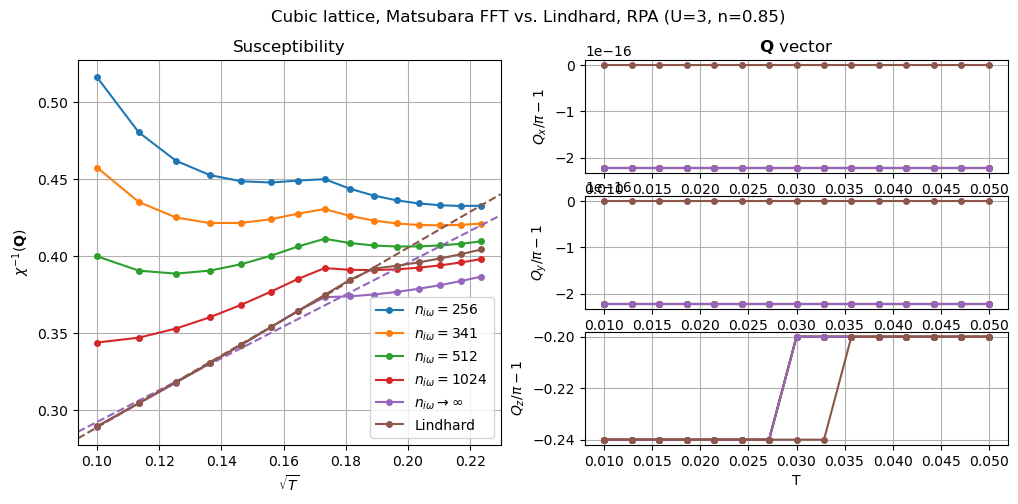

In [23]:
U = 3
n = 0.85
T_list = np.linspace(0.01, 0.05, 15)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Matsubara FFT vs. Lindhard, RPA (U={U}, n={n})'

nk = 50
niw_list = 1024//np.array([4,3,2,1])

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'niw': niw, 'niw_extr': False, 'tp': 0.2, 'refine': False} for niw in niw_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=4)

fig = None
for results in results_list:
    niw = results['niw']
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), fit=False, x_exp=0.5, title=title, label=f'$n_{{i\omega}}={niw}$', figure=fig)

results = sweep_chirpa(par_dict, nk=nk, niw=niw_list[-1], niw_extr=True, tp=0.2, refine=False)
fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), fit=True, x_exp=0.5, title=title, label=r'$n_{{i\omega}}\to\infty$', figure=fig)

results = sweep_chirpa(par_dict, nk=nk, method='lindhard', q_path=([1,1,0], [1,1,1]), tp=0.2, refine=False)
fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), fit=True, x_exp=0.5, title=title, label='Lindhard', figure=fig)

plt.show()

In [7]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.04, 15)

nk = 50
file = f'{save_dir}/nTdiag_U3'
if os.path.exists(file):
    results = HDFread_list(file, ['Xc'])
    n_old = [par_list[0]['n'] for par_list in results['par_list']]
    Tc_old = [x[0] for x in results['Xc']]
    Tc = np.interp(n_list, n_old, Tc_old)
else:
    print(f'file {file} does not exist!')

par_list = []
for i, n in enumerate(n_list):
    par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'lindhard', 'q_path': ([1,1,0], [1,1,1]),
               'fit': True, 'fit_type': [critical1, critical2]} for par_dict in par_list]
results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=12, save_file=file)

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
Starting serial run at: 2026-05-15 16:43:21.357706
Starting serial run at: 2026-05-15 16:43:21.358844
Starting serial run at: 2026-05-15 16:43:21.381709
Starting serial run at: 2026-05-15 16:43:21.381710
Starting serial run at: 2026-05-15 16:43:21.385624
Starting serial run at: 2026-05-15 16:43:21.385625


Starting serial run at: 2026-05-15 16:43:21.429226
Starting serial run at: 2026-05-15 16:43:21.436967
Starting serial run at: 2026-05-15 16:43:21.471164
Starting serial run at: 2026-05-15 16:43:21.471155
Starting serial run at: 2026-05-15 16:43:21.477240
Starting serial run at: 2026-05-15 16:43:21.477359
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    4.9s
[Parallel(n_jobs=12)]: Done   4 out of  24 | elapsed:    5.6s remaining:   28.2s
[Parallel(n_jobs=12)]: Done   7 out of  24 | elapsed:    6.5s remaining:   15.7s
[Parallel(n_jobs=12)]: Done  10 out of  24 | elapsed:    6.9s remaining:    9.6s
[Parallel(n_jobs=12)]: Done  13 out of  24 | elapsed:    8.6s remaining:    7.3s
[Parallel(n_jobs=12)]: Done  16 out of  24 | elapsed:   10.5s remaining:    5.2s
[Parallel(n_jobs=12)]: Done  19 out of  24 | elapsed:   12.0s remaining:    3.2s
[Parallel(n_jobs=12)]: Done  22 out of  24 | elapsed:   12.3s remaining:    1.1s
[Parallel(n_jobs=12)]: Done  24 out of  24 | elapsed:   12.8s fin

[-1.0560672448090438, -1.0128288259436367, -0.9673721290653712, -0.9016649855894661, -0.8601483651677911, -0.829565735948234, -0.7799680941335025, -0.73555734010935, -0.6814036509319279, -0.6368712691074403, -0.5941933400769129, -0.5487753153878224, -0.5026946710523343, -0.45692718358635986, -0.4112088702025757, -0.3654541369762124, -0.31981192425431393, -0.2741863035953553, -0.22854480979508143, -0.18287798049710172, -0.13718473346035018, -0.09146983251632733, -0.0457390404387809, 0.0]
[-1.0551810795882957, -1.0127223139536965, -0.9663294225894468, -0.902235722002779, -0.8607714466854247, -0.8293313316194716, -0.7800326055445863, -0.7355187575524714, -0.6814724990485505, -0.6369610776080805, -0.5941870143881917, -0.5487621520450443, -0.5026941003469534, -0.45692711651211393, -0.4112074526517123, -0.3654541498085272, -0.3198117451461951, -0.2741861891012945, -0.22854476420317857, -0.18287798050337856, -0.13718479920754986, -0.09146990826781996, -0.045739087995560035, 0.0]


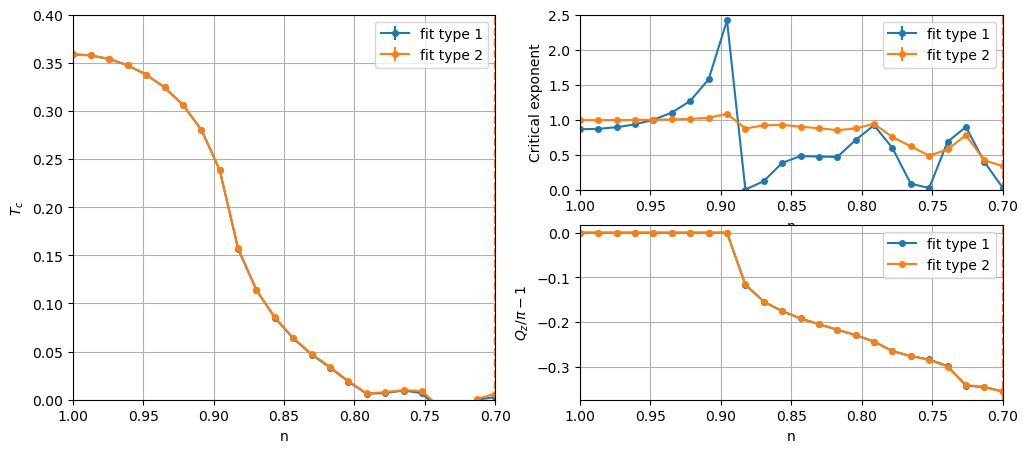

In [33]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.7, 1)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.4)
ax[1].set_ylim(0., 2.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_z/\pi-1$')

results = HDFread_list(f'{save_dir}/nTdiag_U3', ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc', 'mu_c'])
n_fits = len(results['Xc'][0])

for i in range(n_fits):
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[i][-1]-1 for Q in results['Qc']]
    Xc = [x[i] for x in results['Xc']]
    Xc_err = [x[i] for x in results['Xc_err']]
    gamma = [x[i] for x in results['gamma']]
    gamma_err = [x[i] for x in results['gamma_err']]
    mu_c = [x[i] for x in results['mu_c']]
    print(mu_c)

    ax[0].errorbar(n_list, Xc, Xc_err, fmt='o-', label=f"fit type {i+1}", markersize=4)
    ax[1].errorbar(n_list, gamma, gamma_err, fmt='o-', label=f"fit type {i+1}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"fit type {i+1}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., Xc, n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

plt.savefig(f'{save_dir}/fit_type.png', dpi=100)
plt.show()

In [18]:
U = 3
n_list = np.linspace(0.73, 0.91, 12)
T_list = np.linspace(0., 0.04, 15)

nk = 100
niw = 128
tp_list = [0., 0.05, 0.1, 0.15, 0.2]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 'niw': niw, 'niw_extr': True, 'refine': False} for #par_dict in par_list]
    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 
                   'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    #Tc = np.array([res['Xc'] for res in results])
    #i_crit = np.argwhere(Tc > 0)[0,0]
    #n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:   36.7s
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:   37.2s remaining:  1.9min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:   37.5s remaining:   52.6s
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  1.2min remaining:   52.4s
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  1.3min remaining:   25.1s
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  1.3min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-15 16:50:18.950604
Starting serial run at: 2026-05-15 16:50:18.950604
Starting serial run at: 2026-05-15 16:50:18.950745
Starting serial run at: 2026-05-15 16:50:18.951103
Starting serial run at: 2026-05-15 16:50:18.957648
Starting serial run at: 2026-05-15 16:50:18.957655
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:   38.6s
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:   39.4s remaining:  2.0min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:   41.1s remaining:   57.6s
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  1.3min remaining:   56.8s
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  1.4min remaining:   27.1s
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  1.5min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:   39.9s
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:   42.5s remaining:  2.1min
[Parallel(n_jobs=6)]: Done 

Starting serial run at: 2026-05-15 16:53:19.094182
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:   42.2s
/home/ctort/miniconda3/envs/triqs/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:   43.0s remaining:  2.1min
Starting serial run at: 2026-05-15 16:54:01.842926


Starting serial run at: 2026-05-15 16:54:02.370872
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:   44.0s remaining:  1.0min


Starting serial run at: 2026-05-15 16:54:03.446985


Starting serial run at: 2026-05-15 16:54:03.964366
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  1.4min remaining:  1.0min
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  1.4min remaining:   28.8s
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  1.6min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-15 16:54:52.439050
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:   40.5s
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:   42.2s remaining:  2.1min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:   44.2s remaining:  1.0min
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  1.4min remaining:  1.0min
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  1.5min remaining:   29.6s
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  1.6min finished


0.91 0.0 [-0.9481132555863129, -0.8841523777466039, -0.8335072933733159, -0.771012558120248, -0.7175195917152137, -0.6589364963136722, -0.6019023651700948, -0.5445839862467969, -0.4872677574266172, -0.429920945564759, -0.3725154341263059, -0.3152494760228582]
0.91 0.05 [-0.8276521925126368, -0.7741928676226675, -0.710933595723972, -0.6569930999746229, -0.5959265450478491, -0.5403328548246239, -0.4811360788693037, -0.42333713986442373, -0.36551182477340927, -0.30792580666828484, -0.25143867958419897, -0.1948896239808105]
0.91 0.1 [-0.6897738087029504, -0.6699484415999507, -0.5899528010582848, -0.5451680569465912, -0.4797801795867606, -0.41619536544614205, -0.35927406867092715, -0.2991140697956747, -0.2425734874316539, -0.18466610921985382, -0.12950166782155872, -0.07373697166709862]
0.8956186226223128 0.15 [-0.607873054284544, -0.5693637504066569, -0.47431875342747354, -0.4323396170547355, -0.34781451730265084, -0.28290445953564813, -0.23795167911933834, -0.17359904191432474, -0.1208500

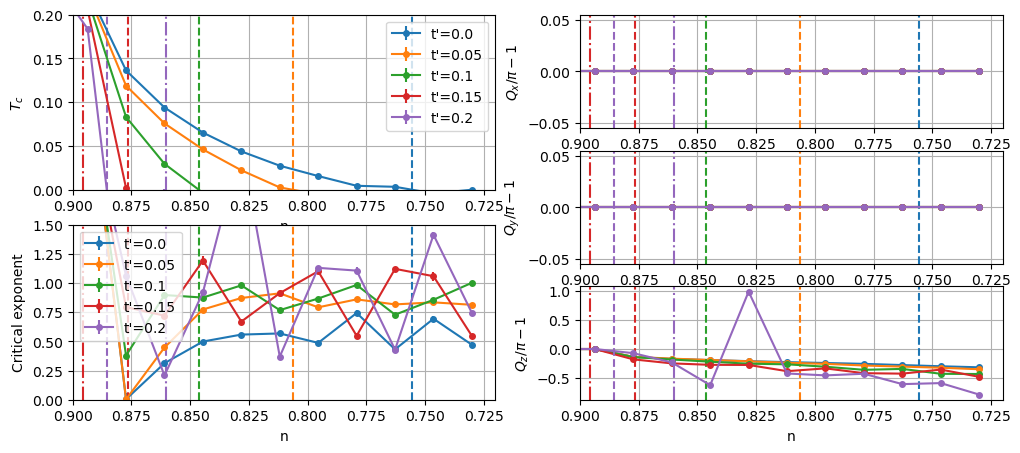

In [32]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.72, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.2)
ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

tp_list = [0., 0.05, 0.1, 0.15, 0.2]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc', 'mu_c'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qj = [[Q[j]-1 for Q in results['Qc']] for j in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    for j, a in enumerate(ax[2:]):
        a.plot(n_list, Qj[j], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    n_crit2 = np.interp(0., results['mu_c'], n_list)
    print(n_crit2, tp, results['mu_c'])
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.axvline(n_crit2, linestyle='-.', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/postp.png', dpi=100)
plt.show()

In [25]:
U = 3
n_list = np.linspace(0.73, 0.91, 12)
T_list = np.linspace(0., 0.04, 15)

nk = 50
niw = 128
tp_list = [-0.05, -0.1, -0.15, -0.2]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 'niw': niw, 'niw_extr': True, 'refine': False} for #par_dict in par_list]
    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 
                   'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    #Tc = np.array([res['Xc'] for res in results])
    #i_crit = np.argwhere(Tc > 0)[0,0]
    #n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
Starting serial run at: 2026-05-15 16:59:33.249822
Starting serial run at: 2026-05-15 16:59:33.249822
Starting serial run at: 2026-05-15 16:59:33.265697
Starting serial run at: 2026-05-15 16:59:33.267767


Starting serial run at: 2026-05-15 16:59:33.322594
Starting serial run at: 2026-05-15 16:59:33.332669
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:    4.5s
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:    4.9s remaining:   14.7s
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:    5.8s remaining:    8.1s
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:    8.2s remaining:    5.9s
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:    8.9s remaining:    3.0s
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:   10.4s finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:    4.0s
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:    4.2s remaining:   12.7s
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:    4.5s remaining:    6.3s
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:    7.4s remaining:    5.3s
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:    8.0s remaining:

0.0 [-0.9481132555863129, -0.8841523777466039, -0.8335072933733159, -0.771012558120248, -0.7175195917152137, -0.6589364963136722, -0.6019023651700948, -0.5445839862467969, -0.4872677574266172, -0.429920945564759, -0.3725154341263059, -0.3152494760228582]
-0.05 [-1.0671951331469793, -1.029137892163836, -0.9184250332785706, -0.8794443103899608, -0.8407183438738781, -0.7861699130581287, -0.7200855528433826, -0.6642551789063457, -0.6078556789003859, -0.5507410611669328, -0.492650789444007, -0.4347943253648767]
-0.1 [-1.1697270091312866, -1.0662378413502094, -1.1038100635492265, -1.0343212995166788, -0.9427828311297325, -0.8879611606798635, -0.8483402924082443, -0.7843265579111319, -0.7272583568513871, -0.6703640148036035, -0.6116662256370465, -0.5534357809834232]
-0.15 [-1.4600158670602825, -1.2787816457031045, -1.1673537588654028, -1.1050007319630677, -1.0946337174266918, -1.0074793012681837, -0.9505731021415931, -0.8966657875207377, -0.8454894209698526, -0.788658340006893, -0.72932355633

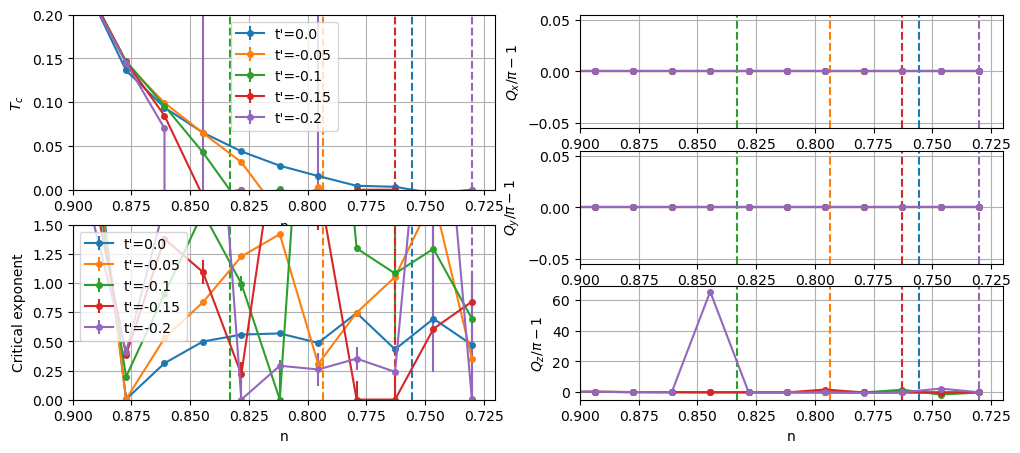

In [30]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.72, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.2)
ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

tp_list = [0., -0.05, -0.1, -0.15, -0.2]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc', 'mu_c'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qj = [[Q[j]-1 for Q in results['Qc']] for j in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    for j, a in enumerate(ax[2:]):
        a.plot(n_list, Qj[j], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    n_crit2 = np.interp(-tp, results['mu_c'], n_list)
    print(tp, results['mu_c'])
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.axvline(n_crit2, linestyle='-.', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/negtp.png', dpi=100)
plt.show()

In [ ]:
save_dir = f'data/{dim}d/rpa_ba'

In [ ]:
U = 3
n_list = np.linspace(0.73, 0.91, 12)
T_list = np.linspace(0., 0.04, 15)

nk = 100
niw = 128
Gamma_list = [0.01, 0.025, 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.3f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'S_iwk_list': -1.j*Gamma, 'niw': niw, 'niw_extr': True, 'refine': False} for par_dict in par_list]
    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'S_iwk_list': -1.j*Gamma,
    #               'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    #Tc = np.array([res['Xc'] for res in results])
    #i_crit = np.argwhere(Tc > 0)[0,0]
    #n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
Starting serial run at: 2026-05-15 05:15:51.299732
Starting serial run at: 2026-05-15 05:15:51.299745


Starting serial run at: 2026-05-15 05:15:51.322664
Starting serial run at: 2026-05-15 05:15:51.326467
Starting serial run at: 2026-05-15 05:15:51.376726
Starting serial run at: 2026-05-15 05:15:51.379596
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  4.9min
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:  5.0min remaining: 14.9min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:  5.0min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  9.8min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  9.9min remaining:  3.3min
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  9.9min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-15 05:25:47.708346
Starting serial run at: 2026-05-15 05:25:47.708349
Starting serial run at: 2026-05-15 05:25:47.708813
Starting serial run at: 2026-05-15 05:25:47.711708
Starting serial run at: 2026-05-15 05:25:47.733452
Starting serial run at: 2026-05-15 05:25:47.733728
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  4.9min
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:  4.9min remaining: 14.8min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:  5.0min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  9.7min remaining:  6.9min
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  9.9min remaining:  3.3min
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  9.9min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-15 05:35:42.790420
Starting serial run at: 2026-05-15 05:35:42.809774
Starting serial run at: 2026-05-15 05:35:42.833245
Starting serial run at: 2026-05-15 05:35:42.836123
Starting serial run at: 2026-05-15 05:35:42.863344
Starting serial run at: 2026-05-15 05:35:42.868472
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  4.8min
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:  5.0min remaining: 14.9min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:  5.0min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  9.7min remaining:  6.9min
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  9.9min remaining:  3.3min
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  9.9min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-15 05:45:37.728594
Starting serial run at: 2026-05-15 05:45:37.728595
Starting serial run at: 2026-05-15 05:45:37.729138
Starting serial run at: 2026-05-15 05:45:37.729590
Starting serial run at: 2026-05-15 05:45:37.733205
Starting serial run at: 2026-05-15 05:45:37.733732
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  4.9min
[Parallel(n_jobs=6)]: Done   3 out of  12 | elapsed:  4.9min remaining: 14.8min
[Parallel(n_jobs=6)]: Done   5 out of  12 | elapsed:  5.0min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   7 out of  12 | elapsed:  9.8min remaining:  7.0min
[Parallel(n_jobs=6)]: Done   9 out of  12 | elapsed:  9.9min remaining:  3.3min
[Parallel(n_jobs=6)]: Done  12 out of  12 | elapsed:  9.9min finished


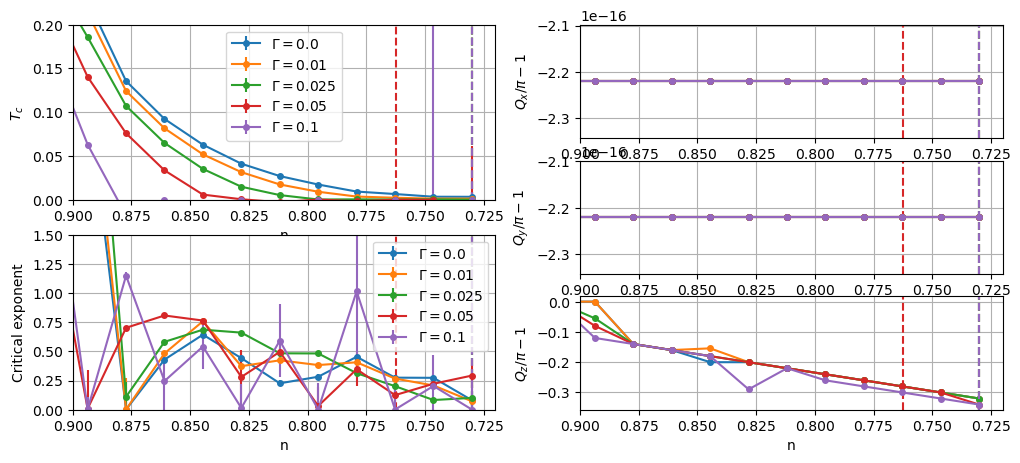

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.72, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.2)
ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

Gamma_list = [0., 0.01, 0.025, 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.3f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qi = [[Q[i]-1 for Q in results['Qc']] for i in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=rf"$\Gamma={Gamma}$", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=rf"$\Gamma={Gamma}$", markersize=4)
    for i, a in enumerate(ax[2:]):
        a.plot(n_list, Qi[i], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/postp.png', dpi=100)
plt.show()

In [3]:
import tracemalloc

tracemalloc.start()
lattice = LATTICE()
nk = 300
lattice.get_k_mesh(nk, ibz=True)
lattice.get_e_k()
print(len(lattice.e_k),'/',nk**3, lattice.e_k)
print(lattice.ibz_w_k.sum())

current, peak = tracemalloc.get_traced_memory()
print(f"peak during fourier: {peak / 1e6:.1f} MB")
tracemalloc.stop()

585276 / 27000000 [-6.         -5.99956137 -5.99824566 ...  5.99912273  5.99956137
  6.        ]
27000000
peak during fourier: 758.7 MB
